In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path("/content/drive/MyDrive/surgical_vlm")

assert PROJECT_ROOT.exists(), f"Project folder not found: {PROJECT_ROOT}"

os.chdir(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Current directory:", Path.cwd())
print("Files:", [p.name for p in PROJECT_ROOT.iterdir()])

Project root: /content/drive/MyDrive/surgical_vlm
Current directory: /content/drive/MyDrive/surgical_vlm
Files: ['README.md', 'debug_dataset.py', 'config.py', 'requirements.txt', 'run_zero_shot.py', 'run_prepare_annotations.py', 'run_prepare_lora_data.py', 'run_evaluation.py', 'run_teacher_label.py', 'notebooks', 'outputs', 'ds', 'scripts', '__pycache__']


In [3]:
!pip install -q torch torchvision transformers accelerate pillow qwen-vl-utils peft bitsandbytes tqdm pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 62.9 MB/s eta 0:00:00


In [4]:
import config

print("Image dir:", config.IMAGE_DIR)
print("Annotation dir:", config.ANNOTATION_DIR)
print("Meta path:", config.META_PATH)

assert config.IMAGE_DIR.exists(), "ds/img not found"
assert config.ANNOTATION_DIR.exists(), "ds/ann not found"
assert config.META_PATH.exists(), "ds/meta.json not found"

print("Dataset verified.")

Image dir: /content/drive/MyDrive/surgical_vlm/ds/img
Annotation dir: /content/drive/MyDrive/surgical_vlm/ds/ann
Meta path: /content/drive/MyDrive/surgical_vlm/ds/meta.json
Dataset verified.


In [5]:
from scripts.data.annotation_builder import ExpertCommunicationAnnotationBuilder
from scripts.data.teacher_labeler import CholecystectomyTeacherLabelBuilder

from scripts.modeling.lora_dataset import LoraDatasetBuilder
from scripts.modeling.zero_shot import QwenZeroShotRunner
from scripts.modeling.lora_train import QwenVLLoraTrainer
from scripts.modeling.lora_inference import QwenLoraInferenceRunner

from scripts.evaluation.evaluator import SurgicalCommunicationEvaluator
from scripts.evaluation.visualization import EvaluationTableBuilder

In [6]:
for path in [
    config.ANNOTATION_OUTPUT_DIR,
    config.ZERO_SHOT_OUTPUT_DIR,
    config.LORA_OUTPUT_DIR,
    config.LORA_ADAPTER_OUTPUT_DIR,
    config.LORA_PREDICTION_OUTPUT_DIR,
    config.EVALUATION_OUTPUT_DIR,
    config.FIGURE_OUTPUT_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Output folders ready.")

Output folders ready.


# Build annotations

In [7]:
builder = ExpertCommunicationAnnotationBuilder(
    image_dir=config.IMAGE_DIR,
    annotation_dir=config.ANNOTATION_DIR,
    meta_path=config.META_PATH,
    output_path=config.EXPERT_ANNOTATION_PATH,
)

samples = builder.build()

splits = builder.split_by_video_id(
    samples=samples,
    train_path=config.TRAIN_JSON_PATH,
    val_path=config.VAL_JSON_PATH,
    test_path=config.TEST_JSON_PATH,
)

print(len(samples), len(splits["train"]), len(splits["val"]), len(splits["test"]))

[INFO] Saved 963 expert annotations to /content/drive/MyDrive/surgical_vlm/outputs/annotations/expert_communication_annotations.json
[INFO] Train samples: 674
[INFO] Val samples: 146
[INFO] Test samples: 143
963 674 146 143


# Build teacher labels

In [8]:
teacher_builder = CholecystectomyTeacherLabelBuilder(
    input_path=config.EXPERT_ANNOTATION_PATH,
    output_path=config.TEACHER_ANNOTATION_PATH,
)

teacher_samples = teacher_builder.build()

teacher_splits = ExpertCommunicationAnnotationBuilder.split_by_video_id(
    samples=teacher_samples,
    train_path=config.TRAIN_TEACHER_JSON_PATH,
    val_path=config.VAL_TEACHER_JSON_PATH,
    test_path=config.TEST_TEACHER_JSON_PATH,
)

print(len(teacher_samples), len(teacher_splits["train"]), len(teacher_splits["val"]), len(teacher_splits["test"]))

[INFO] Saved literature-guided teacher labels to: /content/drive/MyDrive/surgical_vlm/outputs/annotations/teacher_expert_communication_annotations.json
[INFO] Total samples: 963
[INFO] Train samples: 674
[INFO] Val samples: 146
[INFO] Test samples: 143
963 674 146 143


# Prepare LoRA data

In [9]:
for input_path, output_path in [
    (config.TRAIN_TEACHER_JSON_PATH, config.LORA_TRAIN_DATA_PATH),
    (config.VAL_TEACHER_JSON_PATH, config.LORA_VAL_DATA_PATH),
    (config.TEST_TEACHER_JSON_PATH, config.LORA_TEST_DATA_PATH),
]:
    lora_builder = LoraDatasetBuilder(
        input_json_path=input_path,
        output_json_path=output_path,
        project_root=PROJECT_ROOT,
    )
    lora_builder.build()

[INFO] Saved LoRA dataset to: /content/drive/MyDrive/surgical_vlm/outputs/lora_data/qwen_lora_train.json
[INFO] Number of samples: 674
[INFO] Saved LoRA dataset to: /content/drive/MyDrive/surgical_vlm/outputs/lora_data/qwen_lora_val.json
[INFO] Number of samples: 146
[INFO] Saved LoRA dataset to: /content/drive/MyDrive/surgical_vlm/outputs/lora_data/qwen_lora_test.json
[INFO] Number of samples: 143


# Inspect one test image + teacher answer

Sample ID: video09_sequence992_video09_frame_1006_endo
Image: /content/drive/MyDrive/surgical_vlm/ds/img/video09_frame_1006_endo.png
Visible classes: ['liver ligament', 'fat', 'abdominal wall', 'gastrointestinal tract', 'liver']

Teacher answer:
{
  "visible_instruments": [],
  "visible_anatomy_or_tissue": [
    "liver ligament",
    "fat",
    "abdominal wall",
    "gastrointestinal tract",
    "liver"
  ],
  "visible_action": "No surgical instrument is annotated in this frame, so no tool-based action such as traction, dissection, clipping, cauterization, or adhesiolysis should be claimed.",
  "possible_surgical_phase": "uncertain from this single frame",
  "expert_surgical_description": "The annotated visible anatomy or tissue classes are liver ligament, fat, abdominal wall, gastrointestinal tract, and liver. No surgical instrument is annotated in this frame, so no tool-based action such as traction, dissection, clipping, cauterization, or adhesiolysis should be claimed. The liver is

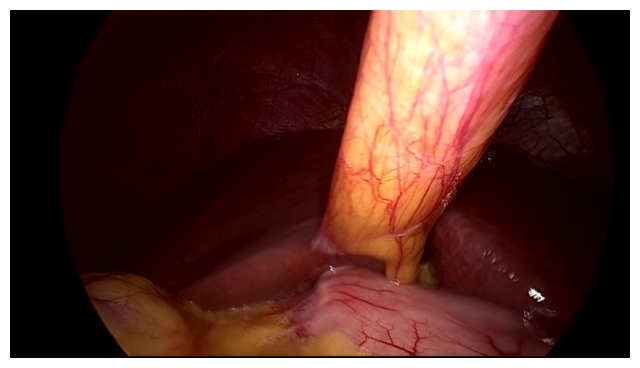

In [15]:
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

with open(config.TEST_TEACHER_JSON_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

sample = test_data[0]
image_path = PROJECT_ROOT / "ds" / "img" / sample["image_filename"]

print("Sample ID:", sample["sample_id"])
print("Image:", image_path)
print("Visible classes:", sample["visible_classes"])

print("\nTeacher answer:")
print(json.dumps(sample["teacher_answer"], indent=2, ensure_ascii=False))

img = Image.open(image_path)
plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

# Zero-shot

In [10]:
runner = QwenZeroShotRunner(
    model_name=config.QWEN_MODEL_NAME,
    input_json_path=config.TEST_TEACHER_JSON_PATH,
    output_json_path=config.ZERO_SHOT_OUTPUT_PATH,
    project_root=PROJECT_ROOT,
    max_samples=20,
)

predictions = runner.run()
print("Predictions:", len(predictions))

[INFO] Loading model: Qwen/Qwen2.5-VL-3B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[INFO] Model loaded successfully.
[INFO] Running zero-shot 1/20: video09_sequence992_video09_frame_1006_endo


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[INFO] Running zero-shot 2/20: video09_sequence992_video09_frame_1008_endo
[INFO] Running zero-shot 3/20: video09_sequence992_video09_frame_1010_endo
[INFO] Running zero-shot 4/20: video09_sequence992_video09_frame_1024_endo
[INFO] Running zero-shot 5/20: video09_sequence992_video09_frame_1030_endo
[INFO] Running zero-shot 6/20: video09_sequence992_video09_frame_1046_endo
[INFO] Running zero-shot 7/20: video09_sequence992_video09_frame_1049_endo
[INFO] Running zero-shot 8/20: video09_sequence992_video09_frame_1056_endo
[INFO] Running zero-shot 9/20: video09_sequence992_video09_frame_1066_endo
[INFO] Running zero-shot 10/20: video09_sequence832_video09_frame_836_endo
[INFO] Running zero-shot 11/20: video09_sequence832_video09_frame_851_endo
[INFO] Running zero-shot 12/20: video09_sequence832_video09_frame_855_endo
[INFO] Running zero-shot 13/20: video09_sequence832_video09_frame_856_endo
[INFO] Running zero-shot 14/20: video09_sequence832_video09_frame_862_endo
[INFO] Running zero-shot 

# Evaluate

In [11]:
evaluator = SurgicalCommunicationEvaluator(
    prediction_path=config.ZERO_SHOT_OUTPUT_PATH,
    output_json_path=config.ZERO_SHOT_EVAL_PATH,
    output_csv_path=config.ZERO_SHOT_EVAL_TABLE_PATH,
)

eval_results = evaluator.run()

[INFO] Saved evaluation JSON to: /content/drive/MyDrive/surgical_vlm/outputs/evaluation/zero_shot_evaluation.json
[INFO] Saved evaluation CSV to: /content/drive/MyDrive/surgical_vlm/outputs/evaluation/zero_shot_evaluation_table.csv

===== Evaluation Summary =====
Samples evaluated: 20
JSON valid: 1.00
Hallucination-free: 0.00
Phase safe: 0.00
Uncertainty present: 1.00
Expert style: 1.00
Average score: 3.00/5


# Table

In [12]:
table_builder = EvaluationTableBuilder(config.ZERO_SHOT_EVAL_PATH)
table_builder.print_markdown_table()

| Metric | Value |
|---|---:|
| Samples | 20 |
| JSON valid rate | 1.00 |
| Hallucination-free rate | 0.00 |
| Phase-safe rate | 0.00 |
| Uncertainty-present rate | 1.00 |
| Expert-style rate | 1.00 |
| Average score | 3.00/5 |


# small LoRA fine-tuning

In [10]:
from scripts.modeling.lora_train import QwenVLLoraTrainer

trainer = QwenVLLoraTrainer(
    model_name=config.QWEN_MODEL_NAME,
    train_json_path=config.LORA_TRAIN_DATA_PATH,
    val_json_path=config.LORA_VAL_DATA_PATH,
    output_dir=config.LORA_ADAPTER_OUTPUT_DIR,
    project_root=PROJECT_ROOT,
    max_train_samples=50,
    max_val_samples=20,
)

adapter_path = trainer.train()

print("Adapter saved at:", adapter_path)

[INFO] Loading model for QLoRA: Qwen/Qwen2.5-VL-3B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 

# LoRA inference

In [11]:
from scripts.modeling.lora_inference import QwenLoraInferenceRunner

lora_runner = QwenLoraInferenceRunner(
    model_name=config.QWEN_MODEL_NAME,
    adapter_path=config.LORA_ADAPTER_OUTPUT_DIR / "final_adapter",
    input_json_path=config.TEST_TEACHER_JSON_PATH,
    output_json_path=config.LORA_PREDICTION_PATH,
    project_root=PROJECT_ROOT,
    max_samples=20,
)

lora_predictions = lora_runner.run()

print("LoRA predictions:", len(lora_predictions))
print("Saved to:", config.LORA_PREDICTION_PATH)

[INFO] Loading base model: Qwen/Qwen2.5-VL-3B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

[INFO] Loading LoRA adapter: /content/drive/MyDrive/surgical_vlm/outputs/lora_adapter/final_adapter


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[INFO] LoRA model ready.
[INFO] Running LoRA inference 1/20: video09_sequence992_video09_frame_1006_endo


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[INFO] Running LoRA inference 2/20: video09_sequence992_video09_frame_1008_endo
[INFO] Running LoRA inference 3/20: video09_sequence992_video09_frame_1010_endo
[INFO] Running LoRA inference 4/20: video09_sequence992_video09_frame_1024_endo
[INFO] Running LoRA inference 5/20: video09_sequence992_video09_frame_1030_endo
[INFO] Running LoRA inference 6/20: video09_sequence992_video09_frame_1046_endo
[INFO] Running LoRA inference 7/20: video09_sequence992_video09_frame_1049_endo
[INFO] Running LoRA inference 8/20: video09_sequence992_video09_frame_1056_endo
[INFO] Running LoRA inference 9/20: video09_sequence992_video09_frame_1066_endo
[INFO] Running LoRA inference 10/20: video09_sequence832_video09_frame_836_endo
[INFO] Running LoRA inference 11/20: video09_sequence832_video09_frame_851_endo
[INFO] Running LoRA inference 12/20: video09_sequence832_video09_frame_855_endo
[INFO] Running LoRA inference 13/20: video09_sequence832_video09_frame_856_endo
[INFO] Running LoRA inference 14/20: vid

# evaluate LoRA

In [12]:
lora_evaluator = SurgicalCommunicationEvaluator(
    prediction_path=config.LORA_PREDICTION_PATH,
    output_json_path=config.LORA_EVAL_PATH,
    output_csv_path=config.LORA_EVAL_TABLE_PATH,
)

lora_eval_results = lora_evaluator.run()

[INFO] Saved evaluation JSON to: /content/drive/MyDrive/surgical_vlm/outputs/evaluation/lora_evaluation.json
[INFO] Saved evaluation CSV to: /content/drive/MyDrive/surgical_vlm/outputs/evaluation/lora_evaluation_table.csv

===== Evaluation Summary =====
Samples evaluated: 20
JSON valid: 1.00
Hallucination-free: 0.00
Phase safe: 0.70
Uncertainty present: 1.00
Expert style: 1.00
Average score: 3.70/5


In [13]:
import pandas as pd
import json

zero_df = pd.read_csv(config.ZERO_SHOT_EVAL_TABLE_PATH)
lora_df = pd.read_csv(config.LORA_EVAL_TABLE_PATH)

comparison = pd.DataFrame({
    "Metric": [
        "Samples",
        "JSON valid rate",
        "Hallucination-free rate",
        "Phase-safe rate",
        "Uncertainty-present rate",
        "Expert-style rate",
        "Average score"
    ],
    "Zero-shot Qwen": [
        len(zero_df),
        zero_df["json_valid"].mean(),
        zero_df["hallucination_free"].mean(),
        zero_df["phase_safe"].mean(),
        zero_df["uncertainty_present"].mean(),
        zero_df["expert_style"].mean(),
        zero_df["total_score_0_to_5"].mean()
    ],
    "LoRA-Qwen": [
        len(lora_df),
        lora_df["json_valid"].mean(),
        lora_df["hallucination_free"].mean(),
        lora_df["phase_safe"].mean(),
        lora_df["uncertainty_present"].mean(),
        lora_df["expert_style"].mean(),
        lora_df["total_score_0_to_5"].mean()
    ]
})

comparison

,Metric,Zero-shot Qwen,LoRA-Qwen
0,Samples,20.0,20.0
1,JSON valid rate,1.0,1.0
2,Hallucination-free rate,0.0,0.0
3,Phase-safe rate,0.0,0.7
4,Uncertainty-present rate,1.0,1.0
5,Expert-style rate,1.0,1.0
6,Average score,3.0,3.7


In [14]:
comparison_path = config.EVALUATION_OUTPUT_DIR / "zero_shot_vs_lora_comparison.csv"
comparison.to_csv(comparison_path, index=False)

print("Saved comparison to:", comparison_path)

Saved comparison to: /content/drive/MyDrive/surgical_vlm/outputs/evaluation/zero_shot_vs_lora_comparison.csv


Conclusion:
This prototype demonstrates a complete surgical VLM adaptation pipeline for Task 5: Expert-Level Surgical Communication. CholecSeg8k annotations were converted into grounded frame-level metadata, then into literature-guided expert communication labels. Qwen2.5-VL-3B was first evaluated zero-shot and showed strong formatting and uncertainty behavior, but poor grounding and unsafe phase inference. After a small LoRA fine-tuning run, phase safety improved substantially, increasing the average evaluation score from 3.00/5 to 3.70/5. The remaining hallucination issue indicates that expert-level surgical communication requires not only language adaptation but also stronger visual grounding and annotation-aware supervision.